# Waveguide physics in FDTD

___

### For our first example in this lecture, let us examine the field distribution inside a waveguide. The incident field is a localized continuous-wave source embedded inside the waveguide.

In [1]:
import meep as mp #imports Meep from your package
import numpy as np #Numerical python package for math operations on matrices and etc
import matplotlib.pyplot as plt #plotting package
import math
import cmath
from IPython.display import Video

Using MPI version 4.1, 1 processes


#### Specify the simulation domain

In [2]:
sx,sy = 16,8 # simulation domain (in microns)
dpml = 1 # thickness of the PML (in microns)
cell = mp.Vector3(sx,sy,0)
pml_layers = [mp.PML(dpml)]

In [3]:
waveguide_thickness = 1 # microns

f_cen = 1/6.666 # central frequency. In MEEP, 1/f_cen is the wavelength in microns. Here, wvl = 6.666 microns
 
sources = [mp.Source(mp.ContinuousSource(frequency=f_cen), 
                     component=mp.Ez, 
                     center=mp.Vector3(-0.5*sx+dpml,0))]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    sources=sources,
                    resolution=10 # resolution => 1/10 = 0.1 microns
                    )

Let us also put a line detector to detect the fields. Remember that since the fields are recorded in time, to get frequency-domain fields, one must perform a time fourier-transform. This is done automatically in MEEP with and `add_dft_fields()` and `get_dft_array()`

In [4]:
dft_field_probe = sim.add_dft_fields([mp.Ez], f_cen, 0,1,
                                     where=mp.Volume(center=mp.Vector3(x=6),
                                                     size=mp.Vector3(0,waveguide_thickness,0 )) ) 

<Axes: xlabel='X', ylabel='Y'>

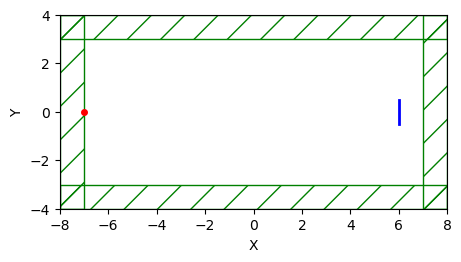

In [5]:
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [6]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(5,animate),
    until=150,
)
Ez_0 = sim.get_dft_array(dft_field_probe,mp.Ez,0) # peforms the fourier transform on the time-domain fields to give frequency-domain fields (E(x,y,\omega))

filename = "waveguide.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.000716107 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 10
time for set_epsilon = 0.0262719 s
-----------
Normalizing field data...
run 0 finished at t = 150.0 (3000 timesteps)
Generating MP4...


Text(0.5, 0, 'y ($\\mu$m)')

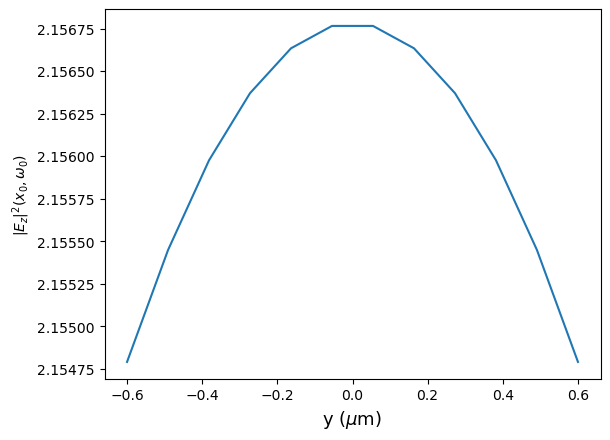

In [7]:
y_line = np.linspace(-Ez_0.shape[0]/2,Ez_0.shape[0]/2,Ez_0.shape[0])*(1/sim.resolution)
plt.plot(y_line,np.abs(Ez_0)**2)
plt.ylabel('$|E_z|^2(x_0,\omega_0)$')
plt.xlabel('y ($\mu$m)',fontsize=13)

___

## Now add the waveguide. The waveguide will have frequency-independent refractive index $n(\lambda)=n=3.5$ and width 1 μm. 

     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

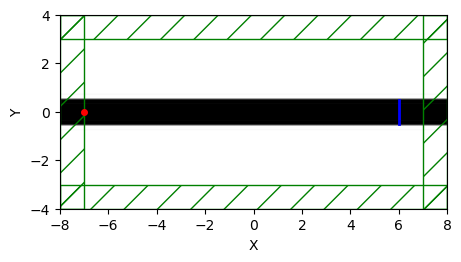

In [8]:
sim.reset_meep()
geometry = [mp.Block(mp.Vector3(mp.inf,waveguide_thickness,mp.inf),
                     center=mp.Vector3(),
                     material=mp.Medium(index=3.5))
                     ] 

sources = [mp.Source(mp.ContinuousSource(frequency=f_cen),
                     component=mp.Ez,
                     center=mp.Vector3(-0.5*sx+dpml,0))]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=10)

dft_field_probe = sim.add_dft_fields([mp.Ez], f_cen, 0,1,
                                     where=mp.Volume(center=mp.Vector3(x=6),
                                                     size=mp.Vector3(0,waveguide_thickness,0 )) ) 

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [9]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(5,animate),
    until=150,
)
Ez_wvg = sim.get_dft_array(dft_field_probe,mp.Ez,0)

filename = "waveguide.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.00108204 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 10
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
time for set_epsilon = 0.0379462 s
-----------
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
Normalizing field data...
run 0 finished at t = 150.0 (3000 timesteps)
Generating MP4...


Text(0.5, 0, 'y ($\\mu$m)')

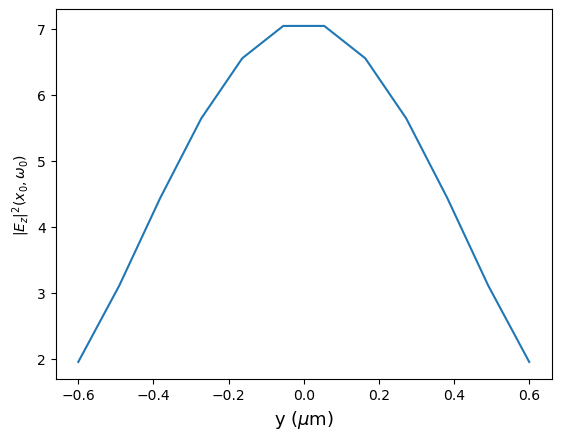

In [10]:
y_line = np.linspace(-Ez_wvg.shape[0]/2,Ez_wvg.shape[0]/2,Ez_wvg.shape[0])*(1/sim.resolution)
plt.plot(y_line,np.abs(Ez_wvg)**2/np.abs(Ez_0)**2)
plt.ylabel('$|E_z|^2(x_0,\omega_0)$')
plt.xlabel('y ($\mu$m)',fontsize=13)

## What if the source is place above the waveguide and not embedded like before?

     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

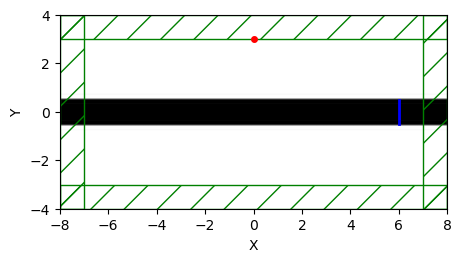

In [ ]:
sim.reset_meep()
sources = [mp.Source(mp.ContinuousSource(frequency=f_cen),
                     component=mp.Ez,
                     center=mp.Vector3(0,0.5*sy - dpml))]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=10)

dft_field_probe = sim.add_dft_fields([mp.Ez], f_cen, 0,1,
                                     where=mp.Volume(center=mp.Vector3(x=6),
                                                     size=mp.Vector3(0,waveguide_thickness,0 )) ) #reflected field's dft

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [12]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(5,animate),
    until=150,
)
Ez_wvg_side = sim.get_dft_array(dft_field_probe,mp.Ez,0)

filename = "waveguide.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.000306966 s
Working in 2D dimensions.
Computational cell is 16 x 8 x 0 with resolution 10
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
time for set_epsilon = 0.0358295 s
-----------
     block, center = (0,0,0)
          size (1e+20,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
Normalizing field data...
run 0 finished at t = 150.0 (3000 timesteps)
Generating MP4...


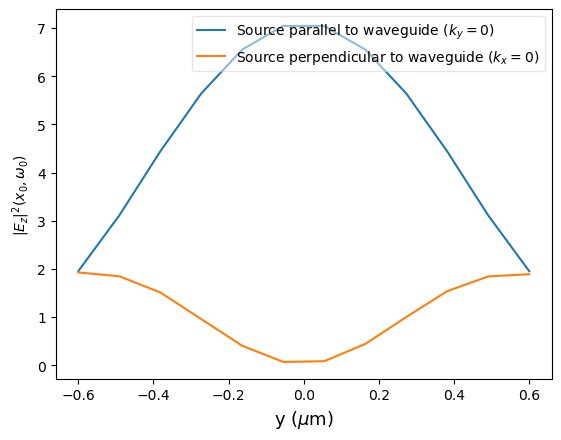

In [13]:
y_line = np.linspace(-Ez_wvg.shape[0]/2,Ez_wvg.shape[0]/2,Ez_wvg.shape[0])*(1/sim.resolution)

plt.plot(y_line,np.abs(Ez_wvg)**2/np.abs(Ez_0)**2,label='Source parallel to waveguide ($k_y=0$)')
plt.plot(y_line,np.abs(Ez_wvg_side)**2/np.abs(Ez_0)**2,label='Source perpendicular to waveguide ($k_x=0$)')
plt.xlabel('y ($\mu$m)',fontsize=13)
plt.ylabel('$|E_z|^2(x_0,\omega_0)$')
plt.legend(loc='upper right',framealpha=0.5,fontsize=10)

___

# Waveguide bend

### In many cases, it is desirable to steer the light into a different directions. In this section, we qualitatively look at waveguide bends and the bending losses.

In [62]:
sim.reset_meep()
sx,sy = 16,8
dpml = 1
cell = mp.Vector3(sx,2*sy)
pml_layers = [mp.PML(dpml)]

geometry = [mp.Block(mp.Vector3(12,waveguide_thickness,mp.inf), # horizontal waveguide
                     center=mp.Vector3(-2.5,-3.5),
                     material=mp.Medium(index=3.5)),

            mp.Block(mp.Vector3(waveguide_thickness,12,mp.inf), # vertical waveguide
                     center=mp.Vector3(3.5,2),
                     material=mp.Medium(index=3.5))]
resolution = 10

sources = [mp.Source(mp.ContinuousSource(wavelength=1/(f_cen), fwidth=1/20),
                     component=mp.Ez,
                     center=mp.Vector3(-7,-3.5),
                     size=mp.Vector3(0,1))]

     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

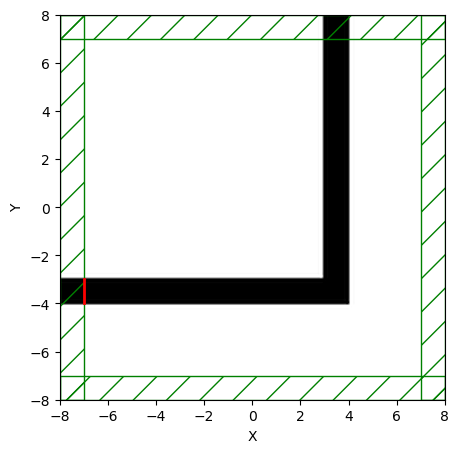

In [63]:
sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [64]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(5,animate),
    until=150,
)
#Ez_wvg_side = sim.get_dft_array(dft_field_probe,mp.Ez,0)

filename = "bent_waveguide.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.000222916 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
time for set_epsilon = 0.0675865 s
-----------
     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
Normalizing field data...
run 0 finished at t = 150.0 (3000 timesteps)
Generating MP4...


Such a waveguide-bend is highly inefficient and almost never used in an application. A better approach is to smoothen the bend.

     cylinder, center = (1,-1,0)
          radius 3.05, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     cylinder, center = (1,-1,0)
          radius 1.95, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-2.05,-1,0)
          size (6.1,6.1,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (2.525,0.525,0)
          size (3.05,3.05,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-4.5,-3.5,0)
          size (11,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,4,0)
          size (1,10,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

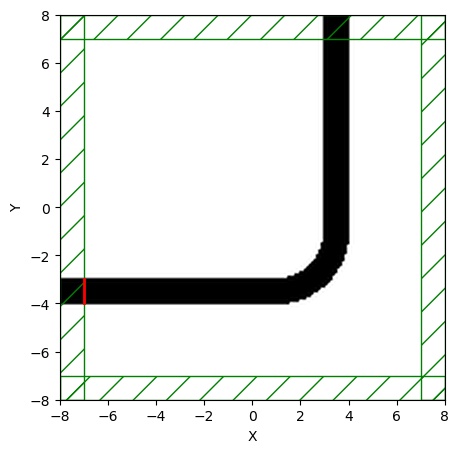

In [65]:
sim.reset_meep()
sx,sy = 16,8
dpml = 1
cell = mp.Vector3(sx,2*sy)
pml_layers = [mp.PML(dpml)]


resolution = 10

sources = [mp.Source(mp.ContinuousSource(frequency=f_cen, width=20),
                     component=mp.Ez,
                     center=mp.Vector3(-7,-3.5),
                     size=mp.Vector3(0,1))]

# -------------------------------------------- Define smooth bend -----------------------------------------------
radius=2.5
wg_width = waveguide_thickness+0.1
x0,y0 = 1,-1
outer_cyl = mp.Cylinder(radius=radius + wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.Medium(index=3.5))
inner_cyl = mp.Cylinder(radius=radius - wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.air)

geometry = [

    outer_cyl,
    inner_cyl,
    # Subtract 2 quadrants to make a quarter circle bend (0 to 90 degrees)
    mp.Block(size=mp.Vector3(2*(radius+wg_width/2), 2*(radius+wg_width/2)),
             center=mp.Vector3(-(radius+wg_width/2)+x0, 0+y0),
             material=mp.air) ,
    mp.Block(size=mp.Vector3(1*(radius+wg_width/2), 1*(radius+wg_width/2)),
             center=mp.Vector3(0.5*(radius+wg_width/2)+x0, y0+0.5*(radius+wg_width/2)),
             material=mp.air) ]

# ----------------------------------------- Add the original waveguides -----------------------------------------

geometry.append(mp.Block(mp.Vector3(11,waveguide_thickness,mp.inf),
                     center=mp.Vector3(-4.5,-3.5),
                     material=mp.Medium(index=3.5)))

geometry.append(     mp.Block(mp.Vector3(waveguide_thickness,10,mp.inf),
                     center=mp.Vector3(3.5,4),
                     material=mp.Medium(index=3.5)))

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)
f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [66]:
animate = mp.Animate2D(f=f, fields=mp.Ez, realtime=False, normalize=True) #Meep object for animating fields

sim.run(
    mp.at_every(5,animate),
    until=150,
)
#Ez_wvg_side = sim.get_dft_array(dft_field_probe,mp.Ez,0)

filename = "smooth_bend_waveguide.mp4"
animate.to_mp4(5, filename)
Video(filename) #generates the video and saves it under the given filename


-----------
Initializing structure...
time for choose_chunkdivision = 0.00025187 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     cylinder, center = (1,-1,0)
          radius 3.05, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     cylinder, center = (1,-1,0)
          radius 1.95, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-2.05,-1,0)
          size (6.1,6.1,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (2.525,0.525,0)
          size (3.05,3.05,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-4.5,-3.5,0)
          size (11,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,4,0)
          size 

___

# Quantitative calculations

### While the above animations are nice for a visual idea of the effects, the results were merely qualitative. This section quantiatively analyses the same waveguide bend and calculates the reflection and transmission. 

In [ ]:
sim.reset_meep()
sx,sy = 16,8
dpml = 1
cell = mp.Vector3(sx,2*sy)
pml_layers = [mp.PML(dpml)]

resolution = 20 # higher resolution now than before 

##### Step 5: Define sources for the simulation. Since we want a range of frequencies now and not just `f_cen`, we must choose a time-pulse inside of a continuous wave. Here we choose a Gaussian pulse in time given by:
$\Large E_{inc}(t) = Ae^{-\frac{(t-t_0)^2}{2\sigma_t^2}}\cos(\omega_0 t)\\$
with $\omega_0= \ $`f_cen` being the center of the frequency. $t_0$ and $\sigma_t$ are determined by the wavelength range of interest, which for us is 300 - 800 nm.

In [51]:
f_min,f_max = 1/7, 1/6
#f_min,f_max = 1/2,1/1.5
f_cen = 0.5*(f_max + f_min)
df = f_max - f_min
sources = [mp.Source(mp.GaussianSource(f_cen,fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(-7,-3.5),
                     size=mp.Vector3(0,1))]

     block, center = (0,-3.5,0)
          size (16,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

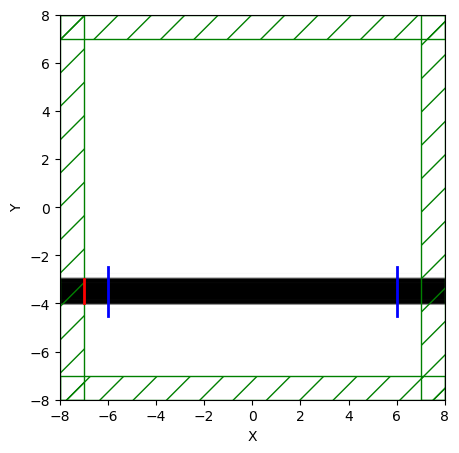

In [52]:
sim.reset_meep()
radius=2.5
wg_width = waveguide_thickness+0.1
x0,y0 = 1,-1
outer_cyl = mp.Cylinder(radius=radius + wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.Medium(index=3.5))
inner_cyl = mp.Cylinder(radius=radius - wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.air)
geometry=[]

geometry.append(mp.Block(mp.Vector3(sx,waveguide_thickness,mp.inf), # only a single waveguide now
                     center=mp.Vector3(0,-3.5),
                     material=mp.Medium(index=3.5)))


sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

refl_fr = mp.FluxRegion(center=mp.Vector3(-7+1,-3.5,0), size=mp.Vector3(0,2*waveguide_thickness,0))

nfreq = 100
refl = sim.add_flux(f_cen, df, nfreq, refl_fr)

# transmitted flux
tran_fr = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-1,-3.5,0), size=mp.Vector3(0,2*waveguide_thickness,0))
tran = sim.add_flux(f_cen, df, nfreq, tran_fr)

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

### Since we now have a gaussian pulse in time, there will be no input flux after a certain point in time. If there are no resonances, the energy in the system will slowly decay and get eventually absorbed by the PMLs. The time-loop must then be terminated in a better way than simply writing `until=t0`. Here, it is terminated when the measurement probe detects flux that is $10^{-3}$ times smaller than previous measurement. 

In [53]:
pt = mp.Vector3(0.5*sx-dpml-0.5,-3.5)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, # how frequently should the tolerance condition be checked in the time loop.
                                                        mp.Ez,
                                                        pt,
                                                        1e-3 # factor by which the fields must decay after every M time steps for termination
                                                        ))

straight_refl_data = sim.get_flux_data(refl)
straight_tran_flux = mp.get_fluxes(tran)

-----------
Initializing structure...
time for choose_chunkdivision = 0.000269755 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     block, center = (0,-3.5,0)
          size (16,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
time for set_epsilon = 0.0609812 s
-----------
field decay(t = 50.050000000000004): 7.823679298222735e-14 / 7.823679298222735e-14 = 1.0
field decay(t = 100.05000000000001): 9.460773728896721e-09 / 9.460773728896721e-09 = 1.0
field decay(t = 150.1): 2.8277816522597217e-05 / 2.8277816522597217e-05 = 1.0
field decay(t = 200.15): 0.0032386674553595966 / 0.0032386674553595966 = 1.0
field decay(t = 250.20000000000002): 0.0270544763913355 / 0.0270544763913355 = 1.0
field decay(t = 300.2): 0.0287836381324466 / 0.0287836381324466 = 1.0
field decay(t = 350.25): 0.011006312145890871 / 0.0287836381324466 = 0.38238085454124415
field decay(t = 400.3): 0.0002181243687295642

-----------
Initializing structure...
time for choose_chunkdivision = 0.000219239 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
time for set_epsilon = 0.0641684 s
-----------
     block, center = (-2.5,-3.5,0)
          size (12,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,2,0)
          size (1,12,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)


<Axes: xlabel='X', ylabel='Y'>

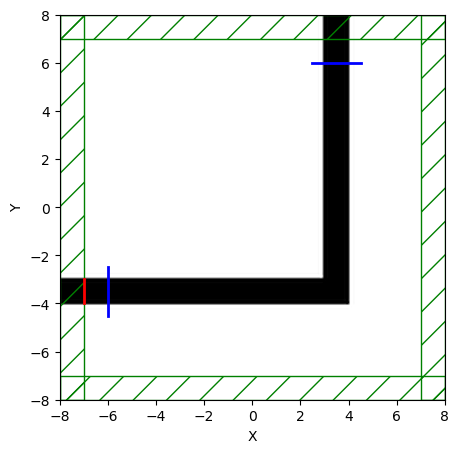

In [54]:
sim.reset_meep()
geometry = [mp.Block(mp.Vector3(12,waveguide_thickness,mp.inf), # horizontal waveguide
                     center=mp.Vector3(-2.5,-3.5),
                     material=mp.Medium(index=3.5)),
            mp.Block(mp.Vector3(waveguide_thickness,12,mp.inf), # vertical waveguide
                     center=mp.Vector3(3.5,2),
                     material=mp.Medium(index=3.5))]

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

# reflected flux
refl = sim.add_flux(f_cen, df, nfreq, refl_fr)

tran_fr = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-3.5,0.5*(2*sy)-dpml-1,0), size=mp.Vector3(2*waveguide_thickness,0,0))
tran = sim.add_flux(f_cen, df, nfreq, tran_fr)

#The reflected fields from the empty simulation must be subtracted from the recorded fields now. Not needed for transmission probe.
sim.load_minus_flux_data(refl, straight_refl_data)

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [55]:
pt = mp.Vector3(0.5*sx-dpml-3.5,0.5*(2*sy)-dpml-1,0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, pt, 1e-3))

bend_refl_flux = mp.get_fluxes(refl)
bend_tran_flux = mp.get_fluxes(tran)

flux_freqs = mp.get_flux_freqs(refl)

field decay(t = 50.050000000000004): 5.0581648470975075e-14 / 5.0581648470975075e-14 = 1.0
field decay(t = 100.05000000000001): 1.8728999845703558e-10 / 1.8728999845703558e-10 = 1.0
field decay(t = 150.1): 4.322886981646191e-09 / 4.322886981646191e-09 = 1.0
field decay(t = 200.15): 5.014002362929166e-05 / 5.014002362929166e-05 = 1.0
field decay(t = 250.20000000000002): 0.0016725120444610277 / 0.0016725120444610277 = 1.0
field decay(t = 300.2): 0.0034807668204531535 / 0.0034807668204531535 = 1.0
field decay(t = 350.25): 0.0029942768898738354 / 0.0034807668204531535 = 0.8602348402884445
field decay(t = 400.3): 0.0002511373671364767 / 0.0034807668204531535 = 0.07215001179072997
field decay(t = 450.35): 1.581613382707109e-06 / 0.0034807668204531535 = 0.00045438647984503657
run 0 finished at t = 450.35 (9007 timesteps)


Plot the results from the recorded fluxes. Remember that the fluxes must be normalized by the results from the first run (no bend).

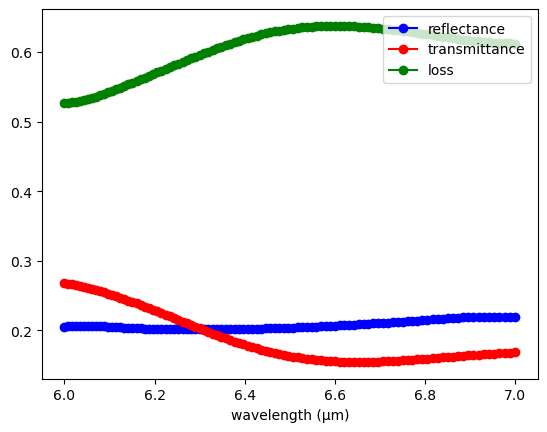

In [56]:
wavelength = []
Reflectance_90bend = []
Transmittance_90bend = []
for i in range(nfreq):
    wavelength = np.append(wavelength, 1/flux_freqs[i])
    Reflectance_90bend = np.append(Reflectance_90bend,-bend_refl_flux[i]/straight_tran_flux[i])
    Transmittance_90bend = np.append(Transmittance_90bend,bend_tran_flux[i]/straight_tran_flux[i])

plt.figure()
plt.plot(wavelength,Reflectance_90bend,'bo-',label='reflectance')
plt.plot(wavelength,Transmittance_90bend,'ro-',label='transmittance')
plt.plot(wavelength,1-Reflectance_90bend-Transmittance_90bend,'go-',label='loss')
plt.xlabel("wavelength (μm)")
plt.legend(loc="upper right")
plt.show()

___

# And now the circular bend

-----------
Initializing structure...
time for choose_chunkdivision = 0.000389333 s
Working in 2D dimensions.
Computational cell is 16 x 16 x 0 with resolution 10
     cylinder, center = (1,-1,0)
          radius 3.05, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     cylinder, center = (1,-1,0)
          radius 1.95, height 1e+20, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-2.05,-1,0)
          size (6.1,6.1,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (2.525,0.525,0)
          size (3.05,3.05,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-4.5,-3.5,0)
          size (11,1,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.25,12.25,12.25)
     block, center = (3.5,4,0)
          size

<Axes: xlabel='X', ylabel='Y'>

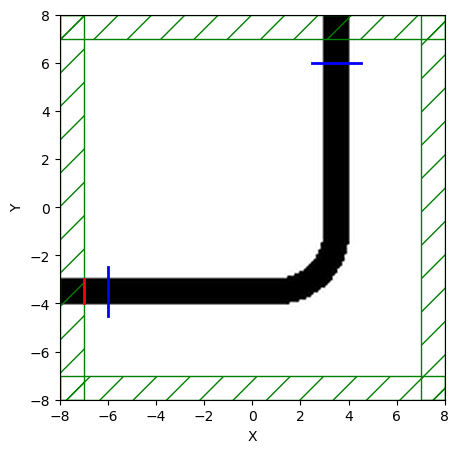

In [57]:
sim.reset_meep()

radius=2.5
wg_width = waveguide_thickness+0.1
x0,y0 = 1,-1
outer_cyl = mp.Cylinder(radius=radius + wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.Medium(index=3.5))
inner_cyl = mp.Cylinder(radius=radius - wg_width/2,
                        center=mp.Vector3(x0,y0),
                        material=mp.air)


geometry = [

    outer_cyl,
    inner_cyl,
    # Subtract 2 quadrants to make a quarter circle bend (0 to 90 degrees)
    mp.Block(size=mp.Vector3(2*(radius+wg_width/2), 2*(radius+wg_width/2)),
             center=mp.Vector3(-(radius+wg_width/2)+x0, 0+y0),
             material=mp.air) ,
    mp.Block(size=mp.Vector3(1*(radius+wg_width/2), 1*(radius+wg_width/2)),
             center=mp.Vector3(0.5*(radius+wg_width/2)+x0, y0+0.5*(radius+wg_width/2)),
             material=mp.air) ]

# ------------------------------------ original waveguides ----------------------------------------------------

geometry.append(mp.Block(mp.Vector3(11,waveguide_thickness,mp.inf),
                     center=mp.Vector3(-4.5,-3.5),
                     material=mp.Medium(index=3.5)))

geometry.append(     mp.Block(mp.Vector3(waveguide_thickness,10,mp.inf),
                     center=mp.Vector3(3.5,4),
                     material=mp.Medium(index=3.5)))

sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution)

# reflected flux
refl = sim.add_flux(f_cen, df, nfreq, refl_fr)

tran_fr = mp.FluxRegion(center=mp.Vector3(0.5*sx-dpml-3.5,0.5*(2*sy)-dpml-1,0), size=mp.Vector3(2*waveguide_thickness,0,0))
tran = sim.add_flux(f_cen, df, nfreq, tran_fr)

#The reflected fields from the empty simulation must be subtracted from the recorded fields now. Not needed for transmission probe.
sim.load_minus_flux_data(refl, straight_refl_data)

f = plt.figure(figsize=(5,5))
ax = f.add_subplot(1,1,1)
sim.plot2D(ax=ax)

In [58]:
pt = mp.Vector3(0.5*sx-dpml-3.5,0.5*(2*sy)-dpml-1,0)

sim.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ez, pt, 1e-3))

bend_refl_flux = mp.get_fluxes(refl)
bend_tran_flux = mp.get_fluxes(tran)
flux_freqs = mp.get_flux_freqs(refl)

wavelength = []
Reflectance_circbend = []
Transmittance_circbend = []
for i in range(nfreq):
    wavelength = np.append(wavelength, 1/flux_freqs[i])
    Reflectance_circbend = np.append(Reflectance_circbend,-bend_refl_flux[i]/straight_tran_flux[i])
    Transmittance_circbend = np.append(Transmittance_circbend,bend_tran_flux[i]/straight_tran_flux[i])

field decay(t = 50.050000000000004): 5.037213153692187e-14 / 5.037213153692187e-14 = 1.0
field decay(t = 100.05000000000001): 8.723689734304403e-10 / 8.723689734304403e-10 = 1.0
field decay(t = 150.1): 2.2985834512675397e-06 / 2.2985834512675397e-06 = 1.0
field decay(t = 200.15): 0.0006338517193327435 / 0.0006338517193327435 = 1.0
field decay(t = 250.20000000000002): 0.016410352599956383 / 0.016410352599956383 = 1.0
field decay(t = 300.2): 0.02768703256348459 / 0.02768703256348459 = 1.0
field decay(t = 350.25): 0.021547070222070454 / 0.02768703256348459 = 0.7782368938478476
field decay(t = 400.3): 0.0013893074402630784 / 0.02768703256348459 = 0.050178993977685604
field decay(t = 450.35): 6.829624321134483e-06 / 0.02768703256348459 = 0.0002466723115044775
run 0 finished at t = 450.35 (9007 timesteps)


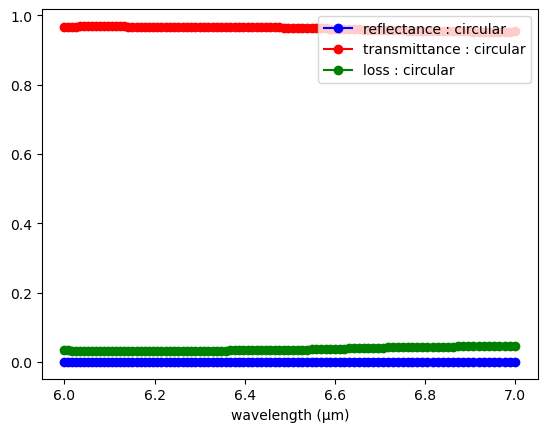

In [60]:
plt.plot(wavelength,Reflectance_circbend,'bo-',label='reflectance : circular')
plt.plot(wavelength,Transmittance_circbend,'ro-',label='transmittance : circular')
plt.plot(wavelength,1-Reflectance_circbend-Transmittance_circbend,'go-',label='loss : circular')
plt.xlabel("wavelength (μm)")
plt.legend(loc="upper right")
plt.show()

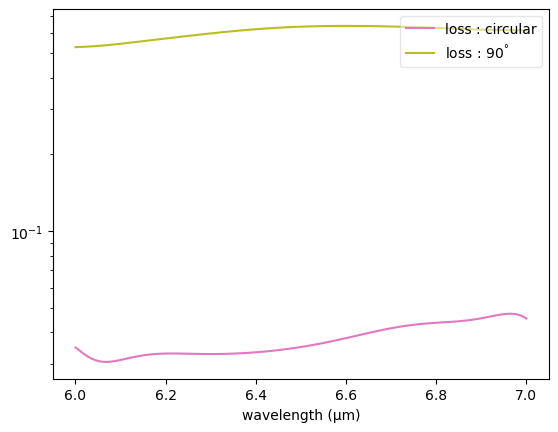

In [61]:
plt.plot(wavelength,1-Reflectance_circbend-Transmittance_circbend,color='tab:pink',label='loss : circular')
plt.plot(wavelength,1-Reflectance_90bend-Transmittance_90bend,color='tab:olive',label='loss : 90$^{\degree}$')
plt.xlabel("wavelength (μm)")
plt.legend(loc="upper right",framealpha=0.5)
plt.yscale('log')

### Interesting sidenote: While such a bend already increases the transmission efficiency significantly compared to the straight bend, for more narrow and sharper bends, researchers often go beyond this design and use non-conventional approaches from [Topology-Optimization](https://meep.readthedocs.io/en/latest/Python_Tutorials/Adjoint_Solver/) for minimizing bending losses.

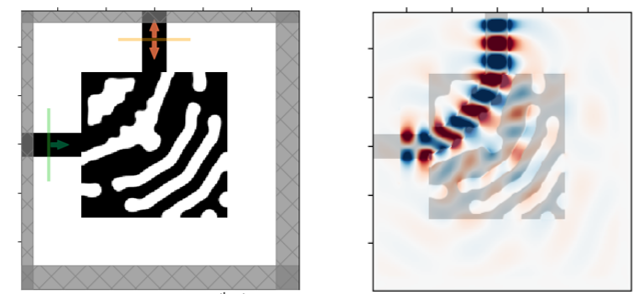